# Очистка данных кафе



## Что делает проект
Очистка сырого датасета продаж (10 000 строк) и сборка двух витрин для еженедельного отчёта.

## Универсальные функции
- `clean_prices` — восстановление пропущенных цен по товару
- `get_top_5` — топ-5 товаров по продажам за день
- `to_snake_case` — перевод названий столбцов в snake_case

## Шаги
1. Осмотр данных
2. Поиск дубликатов, ошибок в ценах
3. Восстановление цен и наименований товаров
4. Приведение Object к нужному формату, Обработка пропусков
5. Сверка с сырыми данными
6. Сборка витрин

In [10]:
import re
import pandas as pd

In [11]:



# Используем "Raw" ссылку (обязательно слово raw.githubusercontent.com)
url = 'https://raw.githubusercontent.com/peneeeee1/junior-analyst-portfolio/main/cafe-data-cleaning/dirty_cafe_sales.csv'
df_before= pd.read_csv(url)
df = pd.read_csv(url)

# Знакомство с данными (первичное)
print(df.head(20))
print(df.info())
print(df.describe())

#Удаляю стобец Total Spent, так как он неудобен для  расчетов в витрине
df = df.drop(columns=['Total Spent'])








   Transaction ID      Item Quantity Price Per Unit Total Spent  \
0     TXN_1961373    Coffee        2            2.0         4.0   
1     TXN_4977031      Cake        4            3.0        12.0   
2     TXN_4271903    Cookie        4            1.0       ERROR   
3     TXN_7034554     Salad        2            5.0        10.0   
4     TXN_3160411    Coffee        2            2.0         4.0   
5     TXN_2602893  Smoothie        5            4.0        20.0   
6     TXN_4433211   UNKNOWN        3            3.0         9.0   
7     TXN_6699534  Sandwich        4            4.0        16.0   
8     TXN_4717867       NaN        5            3.0        15.0   
9     TXN_2064365  Sandwich        5            4.0        20.0   
10    TXN_2548360     Salad        5            5.0        25.0   
11    TXN_3051279  Sandwich        2            4.0         8.0   
12    TXN_7619095  Sandwich        2            4.0         8.0   
13    TXN_9437049    Cookie        5            1.0         5.

['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21' '2023-11-15'
 '2023-06-10' '2023-02-24' '2023-03-25' '2023-01-15' '2023-04-04'
 '2023-03-30' '2023-12-01' '2023-09-18' '2023-06-03' '2023-12-13'
 '2023-04-20' '2023-04-10' '2023-03-11' '2023-06-02' '2023-11-06'
 '2023-08-15' '2023-10-09' '2023-05-28' '2023-07-17' '2023-04-29'
 '2023-06-08' '2023-06-29' '2023-04-17' '2023-12-22' '2023-01-10'
 '2023-10-02' '2023-02-23' '2023-03-22' '2023-11-03' '2023-03-02'
 

"Итого: проделана в меру детальная работа по поиску дублей, но обнаружить их не удалось,\nвозможно руководитель ошибся и дублей в данных нет,если нет то нужно делать более детальный осмотр для\nпоиска.Возможно дубли связаны с наличием в таблице одноверменно и 'UNKNOWN' 'ERROR' и nan"

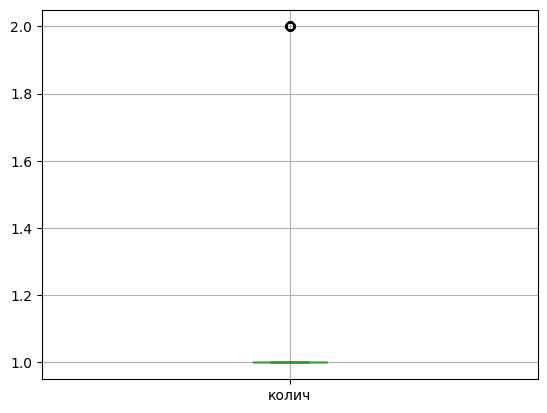

In [12]:
#Работа с дубликатами:
#Просмотр через цикл дублей в названии:

for col in df.columns:
    unique_values = df[col].unique()
    print(unique_values)

"""Полных дублей нет так как id полность уник., в названиях тоже нет(была проверка через цикл),частичные найти
проблематично т.к нет мерила их выявления(ключа). Возможно в столбце с id присутствуют строки не id которые
могут скрыть полные дубликаты."""

#Просмотр наличия уник. значений в столбце с id без TXN

df[~df['Transaction ID'].str.contains('TXN')]['Transaction ID'].unique()
#Пусто

"""Осталось проверить на выбросы в  возможных частичных дублях чтобы посмотреть где возможно есть дубли,
но пока нет ключа что считать за дубли , удалять их нельзя. """
#Просмотр количества повторов строк
result = (
    df.groupby(list(df.columns[1:8]))
      .size()
      .reset_index(name='колич') # Внимание: name (ед.ч.), так как уровень индекса теперь один
      .sort_values('колич', ascending=False)
)
print(result.boxplot())
print(result[result['колич']>1]['колич'].count())
#66 дней из 365 было две строки  с полным повтором информации о покупке(кроме уник. id)


"""Итого: проделана в меру детальная работа по поиску дублей, но обнаружить их не удалось,
возможно руководитель ошибся и дублей в данных нет,если нет то нужно делать более детальный осмотр для
поиска.Возможно дубли связаны с наличием в таблице одноверменно и 'UNKNOWN' 'ERROR' и nan"""



In [18]:

#Поиск ошибок в ценах

"""Возможно менеджер имел в виду ошибка в ценах в несоответствии(наименований товаров 8 а цен возможных
в таблице 6 если только разные виды товаров не имеют одну цену)"""
#Проверка имеют ли некоторые товары одну цену или цена определенных товаров не указана:
result = df[~df['Price Per Unit'].astype(str).str.contains('UNKNOWN|ERROR', na=True)]['Item'].unique()

def clean_prices(df, item_col='Item', price_col='Price Per Unit'):
    """Восстанавливает пропущенные цены по товару.
    Приводит цену к числовому формату, затем заполняет пропуски
    первой валидной ценой внутри группы товара.
    """
    # Приводим к числовому формату, нечисла в NaN
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    # Маска: где цена указана (не NaN), а где заглушка
    has_price = df[price_col].notnull()
    # Для каждой группы (товар) берём первое непустое значение цены
    correct_prices = df.groupby(item_col, dropna=False)[price_col].transform('first')
    # Заполняем только те места, где была заглушка/пустота
    df.loc[~has_price, price_col] = correct_prices[~has_price]

    return df


df = clean_prices(df)

assert df['Price Per Unit'].isnull().sum() == 0, "Остались пропуски в ценах"

"""Итого: вместо 533 строк где была не указана цена, они  заполнены исходя из имеющихся данных, теперь
расчет показателей для отчета получится полнее)"""






#Корректировка форматов столбцов object:

"""(делать вычисления мешают заглушки 'UNKNOWN' и 'ERROR'
для дальнейшей работы они информации не дают поэтому для дальнейших расчетов их нужно  заполнить например
медианой(столбец quantity)."""
#Для выявления медианы нечисловые строки нужно заполнить Nan.:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')
count_valid=df['Quantity'].count()

#Заполняем nan  медианой
df.loc[df['Quantity'].isnull(), 'Quantity'] = df['Quantity'].median()




In [14]:
#Обработка оставшихся пропусков в столбцах необходимых для витрины отчёта":
"""В столбце item если заполнить пропуски по недостающим данным из таблицы, возможно получить
менее точный итог чем в таблице с ценами,так как  одна цена может относится к разным
наименованиям товаров,  лучше заполнить пропуски заглушками nan чтобы гарантированее учесть в расчетах,  строки 'ERROR' и
'UNKNOWN' заполнить исходя из данных получится компромис между возможной дезинформации количества
товаров и стоимости"""
has_item = df['Item'].astype(str).str.contains('UNKNOWN|ERROR', na=True)
correct_item = df.groupby('Price Per Unit', dropna=False)['Item'].transform('first')
df.loc[has_item, 'Item'] = correct_item[has_item]
df.head(20)
"""Обнаружилось что цена 1.5 идет только в паре с error,значит в датасете недостает информации по
определенному продукту,строки 'ERROR' в столбце нужно обозначить специальной заглушкой"""

#Nan на 'Nan','error' на 'товар за 1.5'
df['Item']=df['Item'].fillna('Nan')
df.loc[df['Item'] == 'ERROR', 'Item']='товар за 1.5'



#Обработка столбца с датой
"""Чтобы сделать работу с датой безпаснее ( добавить заглушку) и хранить дату в формате
даты и строки создам 2 столбца (один с заглушкой для агрегации по дате без риска искажения знаменателя) другой для
работы с форматом даты"""



df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
# Создам столбец для агрегации даты
df['Data for agg'] = df['Transaction Date'].dt.strftime('%Y-%m-%d')
df['Data for agg'] = df['Data for agg'].fillna('nan')









In [15]:
#Сверка обработанного датафрейма с сырым для исключения критических ошибок в обработанных данных
cols_to_fix = ['Quantity', 'Price Per Unit']
for col in cols_to_fix:
    df_before[col] = pd.to_numeric(df_before[col], errors='coerce')
print(df_before.describe())
print(df.describe())



          Quantity  Price Per Unit
count  9521.000000     9467.000000
mean      3.028463        2.949984
std       1.419007        1.278450
min       1.000000        1.000000
25%       2.000000        2.000000
50%       3.000000        3.000000
75%       4.000000        4.000000
max       5.000000        5.000000
           Quantity  Price Per Unit               Transaction Date
count  10000.000000     10000.00000                           9540
mean       3.027100         2.94600  2023-07-01 23:00:31.698113280
min        1.000000         1.00000            2023-01-01 00:00:00
25%        2.000000         2.00000            2023-04-01 00:00:00
50%        3.000000         3.00000            2023-07-02 00:00:00
75%        4.000000         4.00000            2023-10-02 00:00:00
max        5.000000         5.00000            2023-12-31 00:00:00
std        1.384614         1.27826                            NaN


In [16]:

#Рачет датасета для недельного отчёта

#Витрина с датой,метриками, датой для агрегации,маска(основная таблица)
df['revenue'] = df['Price Per Unit'] * df['Quantity']
main = df.groupby('Data for agg', as_index=False).agg(
    day_revenue=('revenue', 'sum'),
    count_id=('Transaction ID', 'count')
)
main['check']= main['day_revenue']/main['count_id']
main=main.drop(columns='count_id')
main['Data']=main['Data for agg']
main['Data']=pd.to_datetime(main['Data'],errors='coerce')
main['Data'] = main['Data'].dt.strftime('%Y-%m-%d')
main['Data'] = main['Data'].fillna('nan')
main['Data']=pd.to_datetime(main['Data'],errors='coerce')

#Добавление столбца маски для обозначения будних и выходных
main['is_working_day'] = main['Data'].dt.dayofweek < 6

#Витрина с датой, топ 5 товаров(отдельная таблица)

def get_top_5(df, group_col='Item', sales_col='Продажи за день', n=5):
    """Возвращает топ-N товаров по продажам в каждой группе с рейтингом."""
    top = (
        df.sort_values(sales_col, ascending=False)
          .groupby(group_col)
          .head(n)
          .copy()
    )
    top['Рейтинг'] = top.groupby(group_col).cumcount() + 1
    return top.sort_values([group_col, 'Рейтинг']).reset_index(drop=True)


pre_aggregated = df.groupby(['Data for agg', 'Item'])['Quantity'].sum().reset_index()
pre_aggregated = pre_aggregated.rename(columns={'Quantity': 'Продажи за день'})
top_5 = pre_aggregated.groupby('Data for agg', group_keys=False).apply(get_top_5)


def to_snake_case(text):
    """Функция для перевода названий столбцов в змеиный стиль"""
    text = str(text).lower().strip()
    text = re.sub(r'[\s\-.]+', '_', text)
    text = re.sub(r'[^\w]', '', text)
    # Если название начиналось с цифры  Pandas может выдать ошибку.
    if text[0].isdigit():
        text = f'col_{text}'
    return text

top_5.columns = top_5.columns.map(to_snake_case)
main.columns = main.columns.map(to_snake_case)


for col1, col2 in zip(top_5.columns, main.columns):
    print(col1)
    print(col2)





data_for_agg
data_for_agg
item
day_revenue
продажи_за_день
check
рейтинг
data


/tmp/ipykernel_562/789113717.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5 = pre_aggregated.groupby('Data for agg', group_keys=False).apply(get_top_5)


In [17]:
#Csv выгрузка, итог
main.to_csv('weekly_mart.csv', index=False)
top_5.to_csv('top5_items.csv', index=False)
print(main.head())
print(top_5.head())












  data_for_agg  day_revenue     check       data  is_working_day
0   2023-01-01        185.0  9.250000 2023-01-01           False
1   2023-01-02        180.5  8.595238 2023-01-02            True
2   2023-01-03        206.0  9.809524 2023-01-03            True
3   2023-01-04        263.5  9.759259 2023-01-04            True
4   2023-01-05        337.5  8.881579 2023-01-05            True
  data_for_agg    item  продажи_за_день  рейтинг
0   2023-01-01    Cake             14.0        1
1   2023-01-01  Coffee             16.0        1
2   2023-01-01  Cookie              4.0        1
3   2023-01-01   Juice              6.0        1
4   2023-01-01   Salad              5.0        1
